In [1]:
from datetime import datetime
import numpy as np, pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path
import sys, os
import math
import matplotlib.pyplot as plt
from copy import deepcopy
import time

sys.path.append('../param_estimator')

from vbm_optimizer import VehicleBicycleModelParams, BicycleModelOptimizer, VehiclePlantModel


In [2]:
# setup initial VBM parameters
original_params = VehicleBicycleModelParams(
    4.718, 5.4562, 3.74, 0.15875, 0.17145, 0.04712
)

# Drive cycle parameters
sample_time_s = 0.02
driving_time_s = 60.0
drive_times_s = np.arange(0.0, driving_time_s, sample_time_s)

# speed drive cycle calculations
mean_speed_mps = 2.0
speed_amplitude_mps = 1.0
speed_freq_hz = 0.05
speeds_mps = speed_amplitude_mps * np.sin(2 * math.pi * speed_freq_hz * drive_times_s) + mean_speed_mps

# road wheel angle drive cycle calculations
mean_rwa_rad = 0.0
rwa_amplitude_rad = 0.2
rwa_freq_hz = 0.03
rwas_rad = rwa_amplitude_rad * np.sin(2 * math.pi * rwa_freq_hz * drive_times_s) + mean_rwa_rad


In [3]:
import itertools

def get_kus(param_set):
    return (param_set.lr_m * param_set.mass_kg) / (param_set.cf_Nprad * (param_set.lf_m + param_set.lr_m)) - (param_set.lf_m * param_set.mass_kg) / (param_set.cr_Nprad * (param_set.lf_m + param_set.lr_m))

# DOE Setup - sweep through all parameters under variation with breakpoints of [0.7, 0.85, 1.0, 1.15, 1.3]*original
multiples = [0.85, 0.875, 0.9, 0.925, 0.95, 0.975, 1.0, 1.025, 1.05, 1.075, 1.1, 1.125, 1.15]

lf = original_params.lf_m
lr = original_params.lr_m
cfs = [original_params.cf_Nprad * multiple for multiple in multiples]
crs = [original_params.cr_Nprad * multiple for multiple in multiples]
ms = [original_params.mass_kg * multiple for multiple in multiples]
izs = [original_params.izz_kgm2 * multiple for multiple in multiples]

# combinations = list(itertools.product(cfs, crs, ms, izs))
# combinations = list(itertools.product(cfs, crs, ms, izs))
combinations = list(itertools.product(cfs, crs))

# create a new parameter set for each combination
param_sets, kuss = [], []
for combo in combinations:
    new_vbm_params = VehicleBicycleModelParams(combo[0], combo[1], original_params.mass_kg, lf, lr, original_params.izz_kgm2)
    param_sets.append(new_vbm_params)
    kuss.append(get_kus(new_vbm_params))


In [4]:
FIG_SAVE_LOC = 'figures/doe/'

def get_description_strings(stats):
    filename_prefix = f'paramest_cf_{stats["params_actual"].cf_Nprad:.2f}_cr_{stats["params_actual"].cr_Nprad:.2f}_m_{stats["params_actual"].mass_kg:.2f}_iz_{stats["params_actual"].izz_kgm2:.2f}'
    # pretty_actual_string = f'$C_f$ = {stats["params_actual"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_actual"].cr_Nprad:.2f} N/rad, $m$ = {stats["params_actual"].mass_kg:.2f} kg, $I_z$ = {stats["params_actual"].izz_kgm2:.2f} kgm^2'
    pretty_actual_string = f'$C_f$ = {stats["params_actual"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_actual"].cr_Nprad:.2f} N/rad ($K_{{us}} = {get_kus(stats["params_actual"]):.2f}$)'
    # pretty_pred_string = f'$C_f$ = {stats["params_pred"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_pred"].cr_Nprad:.2f} N/rad, $m$ = {stats["params_pred"].mass_kg:.2f} kg, $I_z$ = {stats["params_pred"].izz_kgm2:.2f} kgm^2'
    pretty_pred_string = f'ESTIMATE: $C_f$ = {stats["params_pred"].cf_Nprad:.2f} N/rad, $C_r$ = {stats["params_pred"].cr_Nprad:.2f} N/rad ($K_{{us}} = {get_kus(stats["params_pred"]):.2f}$)'
    return filename_prefix, pretty_actual_string, pretty_pred_string

def plot_paths(stats):
    
    fig, ax = plt.subplots(1)
    ax.plot(-stats['ys_init'], stats['xs_init'], '--', c='green', label='Initial Path')
    ax.plot(-stats['ys_actual'], stats['xs_actual'], c='red', label='Actual Path')
    ax.plot(-stats['ys_pred'], stats['xs_pred'], c='blue', label='Predicted Path')
    ax.legend()
    ax.set_xlabel('Lateral Distance (m)')
    ax.set_ylabel('Longitudinal Distance (m)')
    ax.grid()
    filename_prefix, pretty_string, pretty_pred_string = get_description_strings(stats)
    fig.suptitle(f'Parameter Estimation DOE Results - {pretty_string}')
    ax.set_title(pretty_pred_string)
    fig.set_size_inches(8, 8)
    fig.set_tight_layout(True)
    fig.savefig(FIG_SAVE_LOC + filename_prefix + '_paths.svg')
    plt.close(fig)
    
def plot_signals(stats):
    
    fig, ax = plt.subplots(5)
    ax[-1].set_xlabel('Time (s)')
    
    ax[0].plot(stats['times'], stats['ys_actual'], c='red', label='Actual Lateral Position')
    ax[0].plot(stats['times'], stats['ys_pred'], c='blue', label='Predicted Lateral Position')
    ax[0].set_ylabel('Position (m)')
    
    ax[1].plot(stats['times'], stats['thetas_actual'], c='red', label='Actual Heading')
    ax[1].plot(stats['times'], stats['thetas_pred'], c='blue', label='Predicted Heading')
    ax[1].set_ylabel('Heading (rad)')

    ax[2].plot(stats['times'], stats['yawrates_actual'], c='red', label='Actual Yaw Rate')
    ax[2].plot(stats['times'], stats['yawrates_pred'], c='blue', label='Predicted Yaw Rate')
    ax[2].set_ylabel('Yaw Rate (rad/s)')
    
    ax[3].plot(stats['times'], stats['ays_actual'], c='red', label='Actual Lateral Accel')
    ax[3].plot(stats['times'], stats['ays_pred'], c='blue', label='Predicted Lateral Accel')
    ax[3].set_ylabel('Lateral Accel (m/s^2)')
    
    ax[4].plot(stats['times'], stats['vys_dot_actual'], c='red', label='Actual Vy Dot')
    ax[4].plot(stats['times'], stats['vys_dot_pred'], c='blue', label='Predicted Vy Dot')
    ax[4].set_ylabel('Vy Dot (m/s^2)')
    
    for a in ax:
        a.legend()
        a.grid()
    
    filename_prefix, pretty_string, pretty_pred_string = get_description_strings(stats)
    fig.suptitle(f'Parameter Estimation DOE Results - {pretty_string}')
    ax[0].set_title(pretty_pred_string)
    fig.set_size_inches(10, 8)
    fig.set_tight_layout(True)
    fig.savefig(FIG_SAVE_LOC + filename_prefix + '_graphs.svg')
    plt.close(fig)
    
def get_param_est_metrics(stats):
    metrics = {}
    metrics['cf_error'] = stats['params_actual'].cf_Nprad - stats['params_pred'].cf_Nprad
    metrics['cr_error'] = stats['params_actual'].cr_Nprad - stats['params_pred'].cr_Nprad
    metrics['mass_error'] = stats['params_actual'].mass_kg - stats['params_pred'].mass_kg
    metrics['iz_error'] = stats['params_actual'].izz_kgm2 - stats['params_pred'].izz_kgm2
    metrics['kus_error'] = get_kus(stats['params_actual']) - get_kus(stats['params_pred'])
    metrics['mean_path_dev'] = np.mean(np.sqrt(np.square(stats['xs_actual'] - stats['xs_pred']) + np.square(stats['ys_actual'] - stats['ys_pred'])))
    metrics['rmse_heading'] = np.sqrt(np.mean(np.square(stats['thetas_actual'] - stats['thetas_pred'])))
    metrics['rmse_yawrate'] = np.sqrt(np.mean(np.square(stats['yawrates_actual'] - stats['yawrates_pred'])))
    metrics['rmse_ay'] = np.sqrt(np.mean(np.square(stats['ays_actual'] - stats['ays_pred'])))
    metrics['rmse_vy_dot'] = np.sqrt(np.mean(np.square(stats['vys_dot_actual'] - stats['vys_dot_pred'])))
    return metrics

def run_param_est_scenario(params):
    
    initial_plant = VehiclePlantModel(deepcopy(original_params), major_sample_time_s=sample_time_s)
    initial_plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_init = np.array(initial_plant.poses)[:,0]
    ys_init = np.array(initial_plant.poses)[:,1]
    
    initial_time = time.process_time()
    
    plant = VehiclePlantModel(deepcopy(params), major_sample_time_s=sample_time_s)
    plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_actual = np.array(plant.poses)[:,0]
    ys_actual = np.array(plant.poses)[:,1]
    thetas_actual = np.array(plant.poses)[:,2]
    yawrates_actual = np.array(plant.states)[:,1]
    ays_actual = np.array(plant.ays)
    vys_dot_actual = np.array(plant.states)[:,0]
    
    vbm_optimizer = BicycleModelOptimizer(deepcopy(original_params), optimize_mass=False, optimize_iz=False)
    costs = vbm_optimizer.optimize_vbm_params(drive_times_s, rwas_rad, speeds_mps, xs_actual, ys_actual, yawrates_actual, thetas_actual, ays_actual, vys_dot_actual)
    
    optimized_plant = VehiclePlantModel(vbm_optimizer.vbm_params, major_sample_time_s=sample_time_s)
    optimized_plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_pred = np.array(optimized_plant.poses)[:,0]
    ys_pred = np.array(optimized_plant.poses)[:,1]
    thetas_pred = np.array(optimized_plant.poses)[:,2]
    yawrates_pred = np.array(optimized_plant.states)[:,1]
    ays_pred = np.array(optimized_plant.ays)
    vys_dot_pred = np.array(optimized_plant.states)[:,0]
    
    final_time = time.process_time()
    
    # plot_paths(xs_actual, ys_actual, xs_pred, ys_pred)
    
    stats = {'params_pred': vbm_optimizer.vbm_params,
            'params_actual': params,
            'times': drive_times_s,
            'xs_actual': xs_actual,
            'ys_actual': ys_actual,
            'thetas_actual': thetas_actual,
            'yawrates_actual': yawrates_actual,
            'ays_actual': ays_actual,
            'vys_dot_actual': vys_dot_actual,
            'xs_pred': xs_pred,
            'ys_pred': ys_pred,
            'thetas_pred': thetas_pred,
            'yawrates_pred': yawrates_pred,
            'ays_pred': ays_pred,
            'vys_dot_pred': vys_dot_pred,
            'xs_init': xs_init,
            'ys_init': ys_init,
            'costs': costs,
            'solve_time': (final_time - initial_time)}
    
    metrics = get_param_est_metrics(stats)
    plot_paths(stats)
    plot_signals(stats)
    
    return {
        'stats': stats,
        'metrics': metrics
    }


In [7]:
param_set = param_sets[160]

metadata = run_param_est_scenario(deepcopy(param_set))

optimized_params = metadata['stats']['params_pred']
print('=============================')
print(f'initial params    : Cf = {original_params.cf_Nprad:.3f}, Cr = {original_params.cr_Nprad:.3f}, m = {original_params.mass_kg:.3f}, iz = {original_params.izz_kgm2:.3f}')
print(f'actual params     : Cf = {param_set.cf_Nprad:.3f}, Cr = {param_set.cr_Nprad:.3f}, m = {param_set.mass_kg:.3f}, iz = {param_set.izz_kgm2:.3f}')
print(f'optimized params  : Cf = {optimized_params.cf_Nprad:.3f}, Cr = {optimized_params.cr_Nprad:.3f}, m = {optimized_params.mass_kg:.3f}, iz = {optimized_params.izz_kgm2:.3f}')


best params: VehicleBicycleModelParams(cf_Nprad=5.352197372991302, cr_Nprad=5.369720825956589, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
initial params    : Cf = 4.718, Cr = 5.456, m = 3.740, iz = 0.047
actual params     : Cf = 5.426, Cr = 5.183, m = 3.740, iz = 0.047
optimized params  : Cf = 5.352, Cr = 5.370, m = 3.740, iz = 0.047


In [8]:
import multiprocessing as mp
import pickle, asyncio

results = {}
run_doe = True

if run_doe:
    # Determine your system's core count
    cores = mp.cpu_count() 

    with mp.Pool(processes=cores) as pool:
        results = pool.map(run_param_est_scenario, param_sets)
            
    # save dataframe for future analysis
    with open(f'data/results.pkl', 'wb') as f:
        pickle.dump(results, f)


best params: VehicleBicycleModelParams(cf_Nprad=4.473844207143423, cr_Nprad=5.413116067231562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.38713058785509, cr_Nprad=5.419476885503461, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.242411215323766, cr_Nprad=5.417705136925937, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.567049764234294, cr_Nprad=5.418675352137618, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.6198385638082415, cr_Nprad=5.415727495201352, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.426512169378226, cr_Nprad=5.416510622459446, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
best params: VehicleBicycleModelParams(cf_Nprad=4.681947181316567, cr_

In [ ]:
def brute_force_sweep(param_set, scalar_options_cf, scalar_options_cr):
    
    k_cf_results, k_cr_results, costs = [], [], []
    all_cost_terms = []
    
    plant = VehiclePlantModel(param_set, major_sample_time_s=sample_time_s, sample_time_s=sample_time_s)
    plant.simulate_over_horizon(rwas_rad, speeds_mps)
    
    xs_actual = np.array(plant.poses)[:,0]
    ys_actual = np.array(plant.poses)[:,1]
    thetas_actual = np.array(plant.poses)[:,2]
    yawrates_actual = np.array(plant.states)[:,1]
    ays_actual = np.array(plant.ays)
    vys_dot_actual = np.array(plant.states)[:,0]
    
    for k_cf in scalar_options_cf:
        for k_cr in scalar_options_cr:
            vbmo = BicycleModelOptimizer(deepcopy(original_params), optimize_mass=False, optimize_iz=False)
            vbmo.times_s = drive_times_s
            vbmo.rwas_rad = rwas_rad
            vbmo.speeds_mps = speeds_mps
            vbmo.xs_actual = xs_actual
            vbmo.ys_actual = ys_actual
            vbmo.thetas_actual = thetas_actual
            vbmo.yrs_actual = yawrates_actual
            vbmo.ays_actual = ays_actual
            vbmo.vys_dot_actual = vys_dot_actual
            vbmo.w_path, vbmo.w_final_drift, vbmo.w_theta, vbmo.w_yawrate, vbmo.w_vy_dot = 0.000, 0.0, 0.000, 1.0, 0.0
            # cost = vbmo.simulate_and_get_cost([k_cf, k_cr])
            cost, cost_terms = vbmo.simulate_and_get_cost([k_cf, k_cr], return_terms=True)
            
            k_cf_results.append(k_cf)
            k_cr_results.append(k_cr)
            costs.append(cost)
            all_cost_terms.append(cost_terms)
            print(k_cf, k_cr, cost)
            
    return {
        'k_cfs': k_cf_results,
        'k_crs': k_cr_results,
        'costs': costs,
        'cost_terms': all_cost_terms,
    }


In [ ]:
k_cf_real, k_cr_real = 0.9, 1.1

real_params = VehicleBicycleModelParams(k_cf_real*original_params.cf_Nprad, k_cr_real*original_params.cr_Nprad, original_params.mass_kg, lf, lr, original_params.izz_kgm2)
sweep_results = brute_force_sweep(real_params, np.arange(0.7, 1.3, 0.03), np.arange(0.7, 1.3, 0.03))


0.7 0.7 0.044698122413849226
0.7 0.73 0.012840153144248996
0.7 0.76 0.0023868455913826194
0.7 0.79 0.002635422214047808
0.7 0.8200000000000001 0.008361417535796323
0.7 0.8500000000000001 0.016855487004806876
0.7 0.8800000000000001 0.02665249198048915
0.7 0.9100000000000001 0.03693887347752854
0.7 0.9400000000000002 0.04725757111310618
0.7 0.9700000000000002 0.05735319118724512
0.7 1.0000000000000002 0.06708725316378845
0.7 1.0300000000000002 0.07639017653689836
0.7 1.0600000000000003 0.08523331655567581
0.7 1.0900000000000003 0.09361231400841527
0.7 1.1200000000000003 0.10153701275968156
0.7 1.1500000000000004 0.10902528139546931
0.7 1.1800000000000004 0.11609920196578971
0.7 1.2100000000000004 0.1227827173490157
0.7 1.2400000000000004 0.12910018901002435
0.7 1.2700000000000005 0.13507552836257103
0.7 1.3000000000000005 0.14073169166830593
0.73 0.7 0.13523182927945263
0.73 0.73 0.055188867576412594
0.73 0.76 0.0189130166485658
0.73 0.79 0.004306507683433018
0.73 0.8200000000000001 0.00

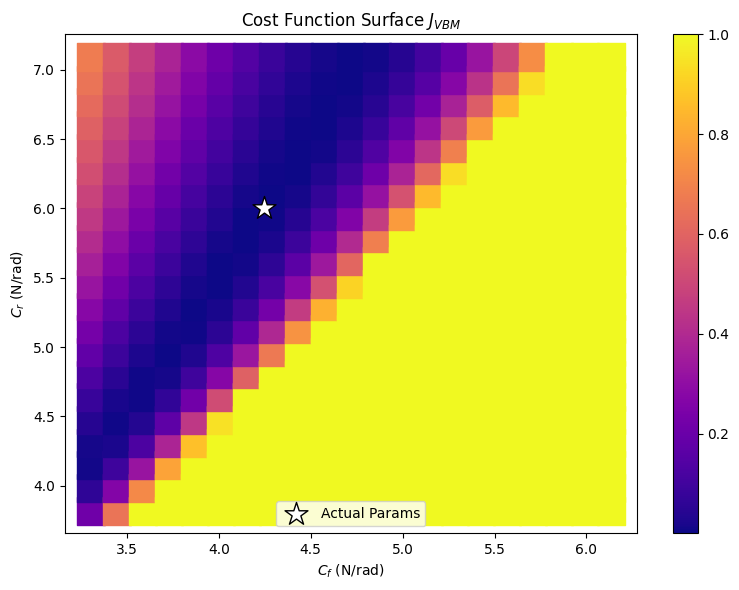

In [ ]:

cost_terms = np.array(sweep_results['cost_terms'])
costs = np.array(sweep_results['costs'])
# print(costs)
norm_costs = [min(c / np.median(costs), 1.0) for c in list(costs)]
# new_costs = cost_terms[:,0] * 0.015 + cost_terms[:,1] * 10.0 + cost_terms[:,4] * 2
# norm_costs = [min(c / np.median(new_costs) , 1.0) for c in new_costs]
sc = plt.scatter(original_params.cf_Nprad * np.array(sweep_results['k_cfs']), original_params.cr_Nprad * np.array(sweep_results['k_crs']), c=norm_costs, s=401, marker='s', cmap='plasma')
plt.colorbar(sc)
plt.scatter([original_params.cf_Nprad*k_cf_real], [original_params.cr_Nprad*k_cr_real], marker='*', c='white', edgecolor='black', s=300, label='Actual Params')
plt.legend()
plt.title('Cost Function Surface $J_{VBM}$')
plt.xlabel('$C_f$ (N/rad)')
plt.ylabel('$C_r$ (N/rad)')
plt.gcf().set_size_inches(8, 6)
# print(costs)
plt.gcf().set_tight_layout(True)
plt.savefig('figures/cost_function_surface_zoomed_out.svg')


In [ ]:
sweep_results_zoomed = brute_force_sweep(real_params, np.arange(4.1, 4.3, 0.005) / original_params.cf_Nprad, np.arange(5.8, 6.2, 0.005) / original_params.cr_Nprad)


0.8690122933446375 1.0630108866977017 0.0004363445528149039
0.8690122933446375 1.0639272753931308 0.0004768164873433407
0.8690122933446375 1.0648436640885597 0.0005190008314281156
0.8690122933446375 1.0657600527839888 0.0005628760473238026
0.8690122933446375 1.0666764414794179 0.0006084208621743182
0.8690122933446375 1.0675928301748467 0.0006556142643953948
0.8690122933446375 1.0685092188702758 0.0007044355001127103
0.8690122933446375 1.069425607565705 0.0007548640696547647
0.8690122933446375 1.070341996261134 0.0008068797240996103
0.8690122933446375 1.071258384956563 0.0008604624618743447
0.8690122933446375 1.072174773651992 0.0009155925254067935
0.8690122933446375 1.073091162347421 0.0009722503978279962
0.8690122933446375 1.0740075510428502 0.0010304167997250697
0.8690122933446375 1.074923939738279 0.0010900726859433818
0.8690122933446375 1.0758403284337081 0.001151199242437295
0.8690122933446375 1.0767567171291372 0.0012137778831684163
0.8690122933446375 1.0776731058245663 0.0012777

KeyboardInterrupt: 

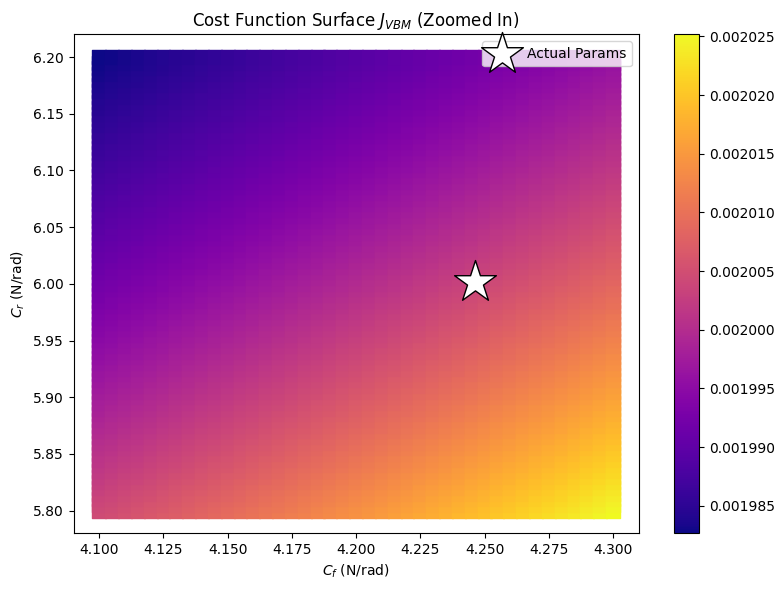

In [ ]:
min_cf, max_cf = 4.1, 4.3
min_cr, max_cr = 5.8, 6.2

cfs = original_params.cf_Nprad * np.array(sweep_results_zoomed['k_cfs'])
crs = original_params.cr_Nprad * np.array(sweep_results_zoomed['k_crs'])

mask = (cfs >= min_cf) & (cfs <= max_cf) & (crs >= min_cr) & (crs <= max_cr)

cost_terms = np.array(sweep_results_zoomed['cost_terms'])
costs = np.array(sweep_results_zoomed['costs'])
# norm_costs = [min(c / 100.0) for c in list(costs)]
# norm_costs = [min(c / np.median(costs) / 500, 0.01) for c in costs]
norm_costs = [min(c / np.median(cost_terms[:,4]) / 500, 0.01) for c in cost_terms[:,4]]
sc = plt.scatter(cfs, crs, c=norm_costs, s=100, marker='s', cmap='plasma')
plt.colorbar(sc)
plt.scatter([original_params.cf_Nprad*k_cf_real], [original_params.cr_Nprad*k_cr_real], marker='*', c='white', edgecolor='black', s=1000, label='Actual Params')
plt.legend()
plt.title('Cost Function Surface $J_{VBM}$ (Zoomed In)')
plt.xlabel('$C_f$ (N/rad)')
plt.ylabel('$C_r$ (N/rad)')
plt.gcf().set_size_inches(8, 6)
plt.gcf().set_tight_layout(True)
plt.savefig('figures/cost_function_surface_zoomed_in.svg')
# print(costs)


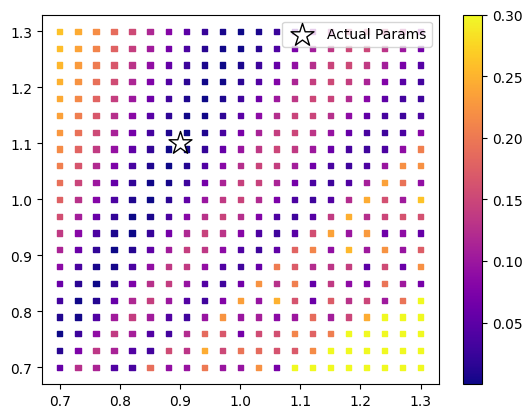

In [ ]:
cost_terms = np.array(sweep_results['cost_terms'])
costs = cost_terms[:,0]
# norm_costs = [min(c / 100.0) for c in list(costs)]
norm_costs = [min(c / np.median(costs) / 10, 0.3) for c in costs]
sc = plt.scatter(sweep_results['k_cfs'], sweep_results['k_crs'], c=norm_costs, s=14, marker='s', cmap='plasma')
plt.colorbar(sc)
plt.scatter([k_cf_real], [k_cr_real], marker='*', c='white', edgecolor='black', s=300, label='Actual Params')
plt.legend()

# plt.xlim(0.7, 1.0)
# print(costs)


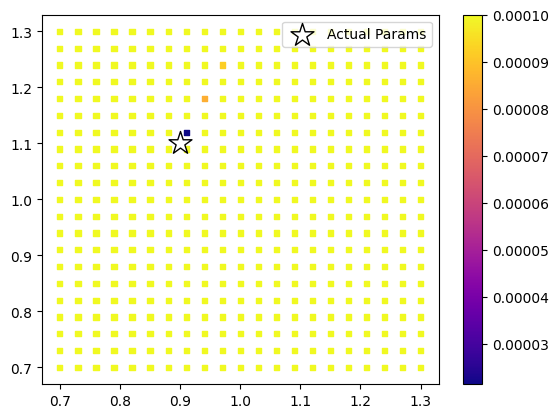

In [ ]:
cost_terms = np.array(sweep_results['cost_terms'])
path_costs = cost_terms[:,0]
accel_costs = cost_terms[:,1]
theta_costs = cost_terms[:,2]
costs = 1 * path_costs + 1 * accel_costs + 1 * theta_costs
# norm_costs = [min(c / 100.0) for c in list(costs)]
norm_costs = [min(c / np.median(costs) / 1, 0.0001) for c in costs]
sc = plt.scatter(sweep_results['k_cfs'], sweep_results['k_crs'], c=norm_costs, s=14, marker='s', cmap='plasma')
plt.colorbar(sc)
plt.scatter([k_cf_real], [k_cr_real], marker='*', c='white', edgecolor='black', s=300, label='Actual Params')
plt.legend()

# plt.xlim(0.7, 1.0)
# print(costs)


In [24]:
all_stats = [result['stats'] for result in results]
all_metrics = [result['metrics'] for result in results]

k_cfs = np.array(list([param_sets[i].cf_Nprad / original_params.cf_Nprad] for i in range(len(all_stats)))).flatten()
k_crs = np.array(list([param_sets[i].cr_Nprad / original_params.cr_Nprad] for i in range(len(all_stats)))).flatten()
cfs = np.array(list([param_sets[i].cf_Nprad] for i in range(len(all_stats)))).flatten()
crs = np.array(list([param_sets[i].cr_Nprad] for i in range(len(all_stats)))).flatten()
cfs_pred = np.array(list([all_stats[i]['params_pred'].cf_Nprad] for i in range(len(all_stats)))).flatten()
crs_pred = np.array(list([all_stats[i]['params_pred'].cr_Nprad] for i in range(len(all_stats)))).flatten()
abs_cf_errors = np.array(list([np.abs(all_metrics[i]['cf_error'])] for i in range(len(all_stats)))).flatten()
abs_cr_errors = np.array(list([np.abs(all_metrics[i]['cr_error'])] for i in range(len(all_stats)))).flatten()
abs_kus_errors = np.array(list([np.abs(all_metrics[i]['kus_error'])] for i in range(len(all_stats)))).flatten()
mean_path_deviations = np.array(list([np.abs(all_metrics[i]['mean_path_dev'])] for i in range(len(all_stats)))).flatten()
rmse_headings = np.array(list([np.abs(all_metrics[i]['rmse_heading'])] for i in range(len(all_stats)))).flatten()
rmse_yawrates = np.array(list([np.abs(all_metrics[i]['rmse_yawrate'])] for i in range(len(all_stats)))).flatten()
rmse_ays = np.array(list([np.abs(all_metrics[i]['rmse_ay'])] for i in range(len(all_stats)))).flatten()
solve_times = np.array(list([np.abs(all_stats[i]['solve_time'])] for i in range(len(all_stats)))).flatten()
kuss = np.array(list([get_kus(param_sets[i])] for i in range(len(all_stats)))).flatten()

results_df = pd.DataFrame(
    dict(zip(
        ['k_cfs', 'k_crs', 'cfs', 'crs', 'kus' 'cfs_pred', 'crs_pred', 'abs_cf_errors', 'abs_cr_errors', 'abs_kus_errors', 'mean_path_deviations', 'rmse_headings', 'rmse_yawrates', 'rmse_ays', 'solve_times', 'kus'],
        [k_cfs, k_crs, cfs, crs, cfs_pred, crs_pred, abs_cf_errors, abs_cr_errors, abs_kus_errors, mean_path_deviations, rmse_headings, rmse_yawrates, rmse_ays, solve_times, kuss]
    ))
)


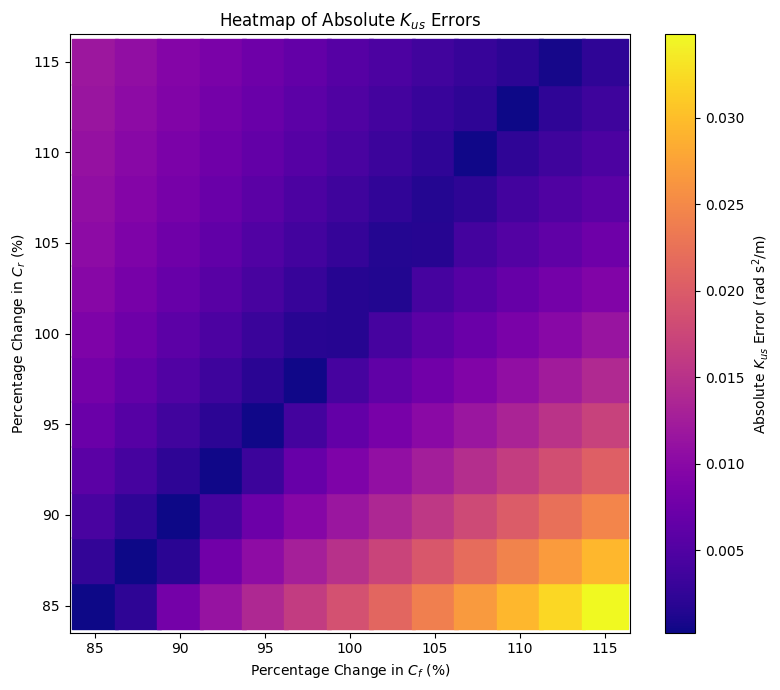

In [65]:
sc = plt.scatter(results_df['k_cfs'] * 100, results_df['k_crs'] * 100, c=results_df['abs_kus_errors'], s=1100, marker='s', cmap='plasma')
plt.colorbar(sc, label='Absolute $K_{us}$ Error (rad s$^2$/m)')
plt.title('Heatmap of Absolute $K_{us}$ Errors')
plt.xlabel('Percentage Change in $C_f$ (%)')
plt.ylabel('Percentage Change in $C_r$ (%)')
plt.gcf().set_size_inches(8, 7)
plt.tight_layout()
plt.savefig('figures/param_est_doe_abs_kus_error_heatmap.svg')


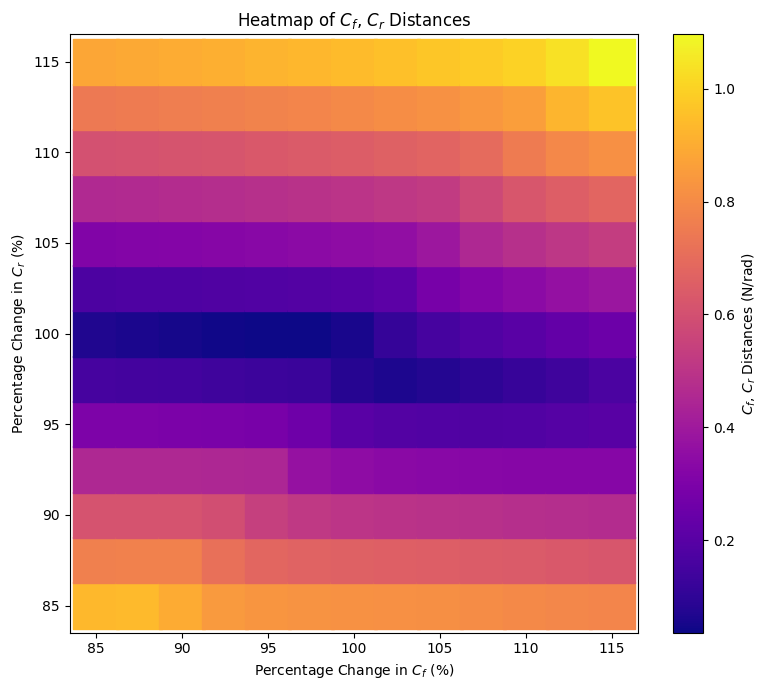

In [66]:
cf_cr_distances = np.sqrt(np.square(results_df['abs_cf_errors']) + np.square(results_df['abs_cr_errors']))
sc = plt.scatter(results_df['k_cfs'] * 100, results_df['k_crs'] * 100, c=cf_cr_distances, s=1100, marker='s', cmap='plasma')
plt.colorbar(sc, label='$C_f$, $C_r$ Distances (N/rad)')
plt.title('Heatmap of $C_f$, $C_r$ Distances')
plt.xlabel('Percentage Change in $C_f$ (%)')
plt.ylabel('Percentage Change in $C_r$ (%)')
plt.gcf().set_size_inches(8, 7)
plt.tight_layout()
plt.savefig('figures/param_est_doe_cf_cr_distance_error_heatmap.svg')


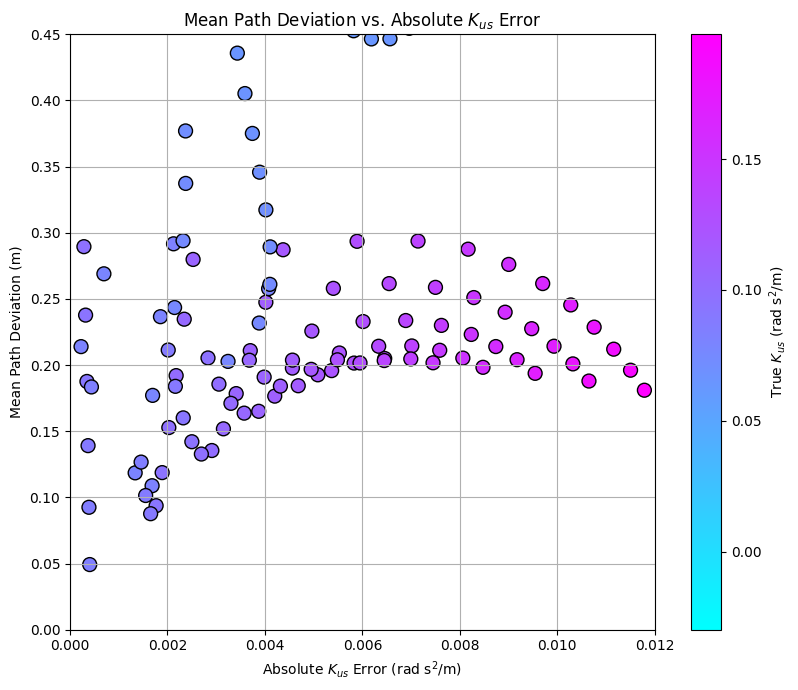

In [71]:
init_cf_cr_distances = np.sqrt(np.square(1 - results_df['k_cfs']) + np.square(1 - results_df['k_crs']))
sc = plt.scatter(results_df['abs_kus_errors'], results_df['mean_path_deviations'], c=results_df['kus'], cmap='cool', edgecolor='black', s=100)
# sc = plt.scatter(cf_cr_distances, results_df['mean_path_deviations'])
plt.colorbar(sc, label='True $K_{us}$ (rad s$^2$/m)')
plt.title('Mean Path Deviation vs. Absolute $K_{us}$ Error')
plt.xlabel('Absolute $K_{us}$ Error (rad s$^2$/m)')
plt.ylabel('Mean Path Deviation (m)')
plt.gcf().set_size_inches(8, 7)
plt.tight_layout()
plt.grid()
# plt.xlim(0, 0.015)
# plt.ylim(0, 1)
plt.savefig('figures/param_est_doe_path_deviation_vs_abs_kus_error_zoomed_out.svg')

plt.xlim(0, 0.012)
plt.ylim(0, 0.45)
plt.savefig('figures/param_est_doe_path_deviation_vs_abs_kus_error_zoomed_in.svg')


In [28]:
kus_ranges = [[-0.05, 0], [0.00, 0.05], [0.05, 0.10], [0.10, 0.15], [0.15, 0.20], [-100, 100]]
kus_range_labels = ['< 0.00', '[0.00, 0.05)', '[0.05, 0.10)', '[0.10, 0.15)', '>= 0.20', 'EVERYTHING']
data_ranges = [results_df[(results_df['kus'] >= r[0]) & (results_df['kus'] < r[1])] for r in kus_ranges]
# [print(len(d)) for d in data_ranges]

for idx, data_range in enumerate(data_ranges):
    
    print(f'=================== True Kus Range: {kus_range_labels[idx]} =======================')
    print(f'Mean Abs Cf Error (N/rad): {np.mean(data_range["abs_cf_errors"]):.3f}')
    print(f'Mean Abs Cr Error (N/rad): {np.mean(data_range["abs_cr_errors"]):.3f}')
    print(f'Mean Abs Kus Error (m): {np.mean(data_range["abs_kus_errors"]):.3f}')
    print(f'Mean Path Deviation (m): {np.mean(data_range["mean_path_deviations"]):.3f}')
    print(f'Mean RMS Heading Error (rad): {np.mean(data_range["rmse_headings"]):.3f}')
    print(f'Mean RMS Yaw Rate Error (rad/s): {np.mean(data_range["rmse_yawrates"]):.3f}')
    print(f'Mean RMS Lateral Acceleration Error (m/s^2): {np.mean(data_range["rmse_ays"]):.3f}')
    print(f'Mean Solve Time (s): {np.mean(data_range["solve_times"]):.3f}')


=================== True Kus Range: < 0.00 =======================
Mean Abs Cf Error (N/rad): 0.242
Mean Abs Cr Error (N/rad): 0.619
Mean Abs Kus Error (m): 0.028
Mean Path Deviation (m): 4.471
Mean RMS Heading Error (rad): 0.690
Mean RMS Yaw Rate Error (rad/s): 0.376
Mean RMS Lateral Acceleration Error (m/s^2): 0.845
Mean Solve Time (s): 45.052
=================== True Kus Range: [0.00, 0.05) =======================
Mean Abs Cf Error (N/rad): 0.201
Mean Abs Cr Error (N/rad): 0.355
Mean Abs Kus Error (m): 0.014
Mean Path Deviation (m): 1.520
Mean RMS Heading Error (rad): 0.212
Mean RMS Yaw Rate Error (rad/s): 0.111
Mean RMS Lateral Acceleration Error (m/s^2): 0.266
Mean Solve Time (s): 45.878
=================== True Kus Range: [0.05, 0.10) =======================
Mean Abs Cf Error (N/rad): 0.297
Mean Abs Cr Error (N/rad): 0.425
Mean Abs Kus Error (m): 0.004
Mean Path Deviation (m): 0.334
Mean RMS Heading Error (rad): 0.037
Mean RMS Yaw Rate Error (rad/s): 0.023
Mean RMS Lateral Accele

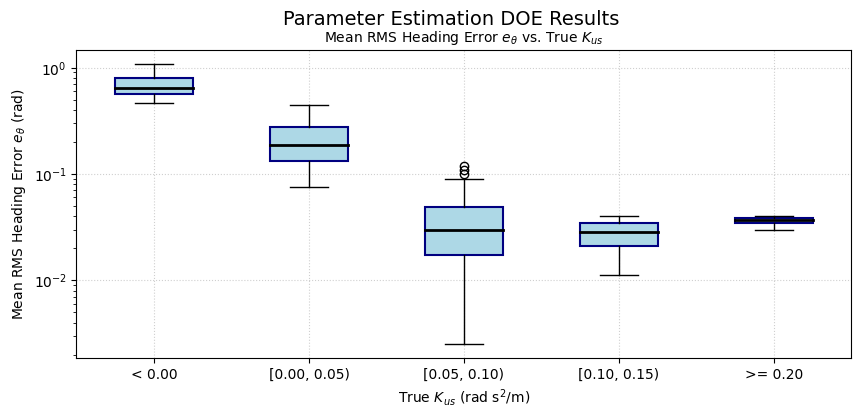

In [69]:
import matplotlib.pyplot as plt

plt.gcf().set_size_inches(10, 4)

plt.boxplot([group['rmse_headings'] for group in data_ranges[0:-1]], labels=kus_range_labels[0:-1],
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5))

plt.xlabel('True $K_{us}$ (rad s$^2$/m)')
plt.ylabel('Mean RMS Heading Error $e_{\\theta}$ (rad)')
# plt.legend(loc='upper left')
plt.suptitle('Parameter Estimation DOE Results', fontsize=14)
plt.gca().set_title('Mean RMS Heading Error $e_{\\theta}$ vs. True $K_{us}$', fontsize=10)
plt.yscale('log')
# plt.ylim(0.035, 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('figures/param_est_doe_rms_heading_boxplot.svg')



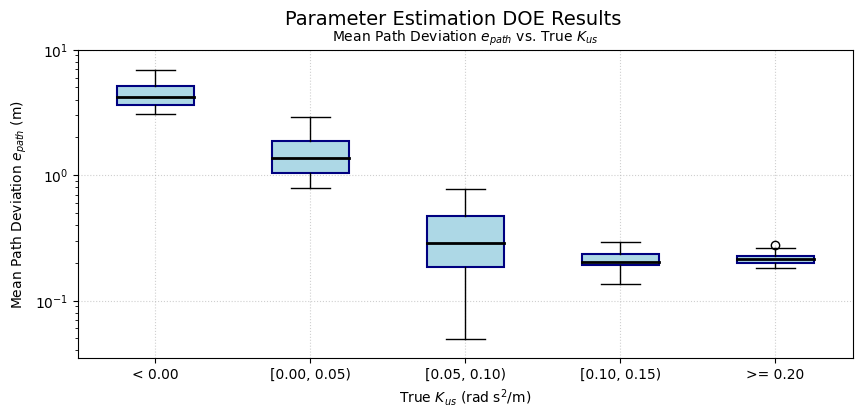

In [70]:
import matplotlib.pyplot as plt

plt.gcf().set_size_inches(10, 4)

plt.boxplot([group['mean_path_deviations'] for group in data_ranges[0:-1]], labels=kus_range_labels[0:-1],
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5))

plt.xlabel('True $K_{us}$ (rad s$^2$/m)')
plt.ylabel('Mean Path Deviation $e_{path}$ (m)')
# plt.legend(loc='upper left')
plt.suptitle('Parameter Estimation DOE Results', fontsize=14)
plt.gca().set_title('Mean Path Deviation $e_{path}$ vs. True $K_{us}$', fontsize=10)
plt.yscale('log')
plt.ylim(0.035, 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('figures/param_est_doe_mean_path_boxplot.svg')



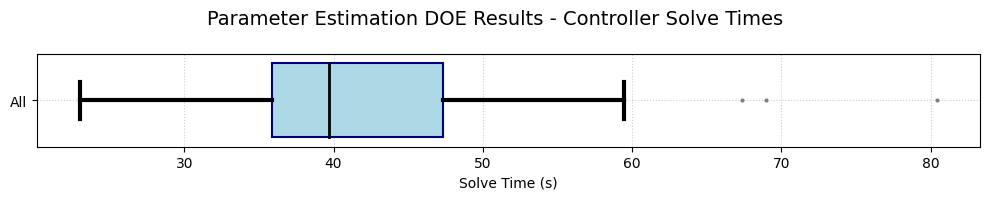

In [58]:
import matplotlib.pyplot as plt

plt.gcf().set_size_inches(10, 2)

all_solve_times = results_df['solve_times']

plt.boxplot(all_solve_times, labels=['All'], widths=0.8,
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5), vert=False, 
            flierprops={
                'markersize': 3,            # Smaller size
                'markerfacecolor': 'gray',  # Muted color
                'markeredgecolor': 'none',  # Remove border outline
                'marker': 'o'               # Shape style ('o', 'x', etc.)
            },whiskerprops=dict(linewidth=3.0),  # Thickens the vertical whisker lines
            capprops=dict(linewidth=3.0))

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('Solve Time (s)')
# plt.ylabel('Solve Time')
# plt.legend(loc='upper left')
plt.suptitle('Parameter Estimation DOE Results - Controller Solve Times', fontsize=14)
# plt.gca().set_title('Controller Solve Times', fontsize=10)
# plt.xlim(0.0, 0.025)
plt.gcf().set_tight_layout(True)
plt.savefig('figures/param_est_doe_solvetime_boxplot.svg')
